In [9]:
# Import necessary libraries
import pandas
import torch
import numpy as np
import random
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, DotProduct
from sklearn.model_selection import train_test_split
import pandas as pd    

# Set random seeds for reproducibility
def set_seed(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)

# Set the path to the dataset
data_path = "../data/TrainingData.csv"

## Data Pre-Processing

In [10]:
# Load the dataset, including missing headers and assigning column names
df = pd.read_csv(data_path, header=None, names=['W1', 'W2', 'R', 't', 'stress'])

# Display basic information about the dataset
sep = '-' * 100
for section in [df.head(), df.shape, df.describe()]:
    print(sep)
    print(section)
print(sep)
df.info()

----------------------------------------------------------------------------------------------------
         W1        W2         R         t     stress
0  0.582950  0.107011  0.069374  0.011457  46.518344
1  0.369159  0.149933  0.035845  0.015876  64.191560
2  0.604024  0.116061  0.039592  0.018931  34.929668
3  0.346207  0.121982  0.046125  0.014213  54.444952
4  0.358780  0.146316  0.030862  0.016575  64.447268
----------------------------------------------------------------------------------------------------
(50, 5)
----------------------------------------------------------------------------------------------------
              W1         W2          R          t     stress
count  50.000000  50.000000  50.000000  50.000000  50.000000
mean    0.500107   0.124957   0.050005   0.014990  48.068301
std     0.116628   0.014626   0.011624   0.002920   9.882066
min     0.303432   0.100323   0.030657   0.010102  31.330892
25%     0.400585   0.112721   0.040231   0.012515  40.076991
50%  

## GPR Model

In [11]:
# Initialize the StandardScaler for feature scaling - transformes feature to have a mean of 0 and a standard deviation of 1
scaler = StandardScaler()

# Define the GPR model kernels
kernel = RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0) + DotProduct(sigma_0=1.0)
gpr = GaussianProcessRegressor(kernel=kernel, random_state=42)

# Extract features and target variable
X = df[['W1', 'W2', 'R', 't']].values
y = df['stress'].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit the GPR model to the training data
gpr.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred, y_std = gpr.predict(X_test_scaled, return_std=True)

# Display the predictions and their standard deviations
print("Predictions:", y_pred)
print("Standard Deviations:", y_std)

Predictions: [45.70163088 45.57629363 45.55621721 49.77461608 54.31002163 50.73845042
 42.26116019 45.99235741 52.28075397 47.57767375]
Standard Deviations: [6.58122451 6.64470595 6.57635627 6.46350671 6.49070563 6.55741507
 6.51581048 6.50781005 6.6000858  6.52949261]


/opt/anaconda3/envs/data-driven/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Fold MAPEs (%): [11.1286618   8.66001172 10.68888333 12.35552169 14.48482134]
Average MAPE (%): 11.4636


/opt/anaconda3/envs/data-driven/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/envs/data-driven/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/envs/data-driven/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda

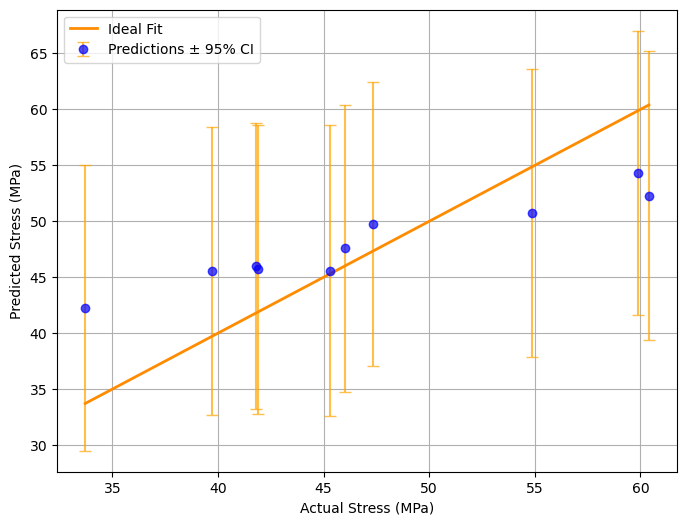

In [12]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Evaluate model error using a pipeline so scaling is applied within each CV fold
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('gpr', GaussianProcessRegressor(kernel=kernel, random_state=42))
])
scores = cross_val_score(pipeline, X, y, cv=5, scoring='neg_mean_absolute_percentage_error')
mean_mape = -100 * scores.mean()

print(f'Fold MAPEs (%): {-100 * scores}')
print(f'Average MAPE (%): {mean_mape:.4f}')

# Plot predicted vs actual stress with 95% confidence interval as error bars
plt.figure(figsize=(8, 6))
plt.errorbar(y_test, y_pred, yerr=1.96 * y_std,
             fmt='o', color='blue', ecolor='orange', elinewidth=1.5,
             capsize=4, alpha=0.7, label='Predictions ± 95% CI')
bounds = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(bounds, bounds, color='darkorange', lw=2, label='Ideal Fit')
plt.xlabel('Actual Stress (MPa)')
plt.ylabel('Predicted Stress (MPa)')
plt.legend()
plt.grid(True)
plt.show()
